In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet

In [5]:
from google.colab import files
uploaded = files.upload()

Saving train_aWnotuB.csv to train_aWnotuB.csv


In [8]:
df = pd.read_csv("train_aWnotuB.csv")

In [9]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [10]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')

In [11]:
df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month
df['year'] = df['DateTime'].dt.year
df['weekday'] = df['DateTime'].dt.weekday

In [12]:
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

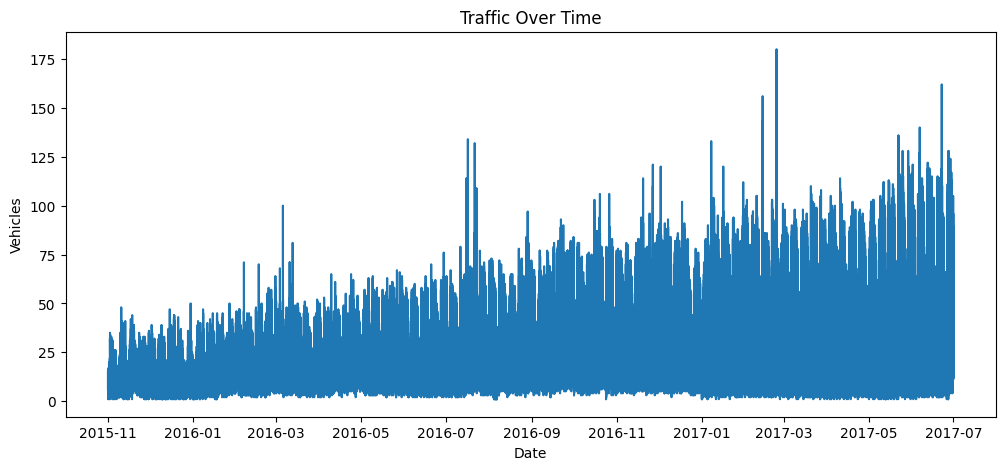

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['DateTime'], df['Vehicles'])
plt.title("Traffic Over Time")
plt.xlabel("Date")
plt.ylabel("Vehicles")
plt.show()

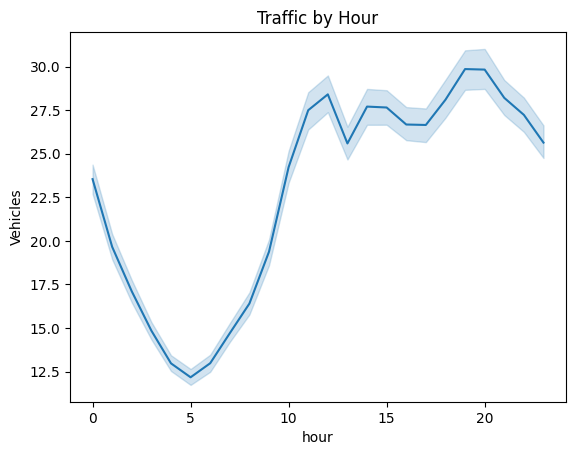

In [14]:
import seaborn as sns

sns.lineplot(x='hour', y='Vehicles', data=df)
plt.title("Traffic by Hour")
plt.show()

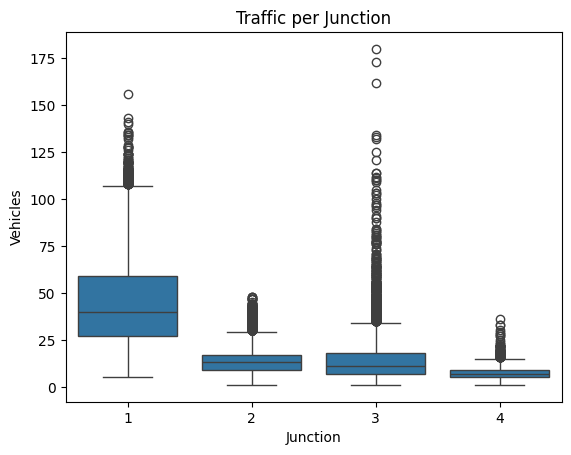

In [15]:
sns.boxplot(x='Junction', y='Vehicles', data=df)
plt.title("Traffic per Junction")
plt.show()

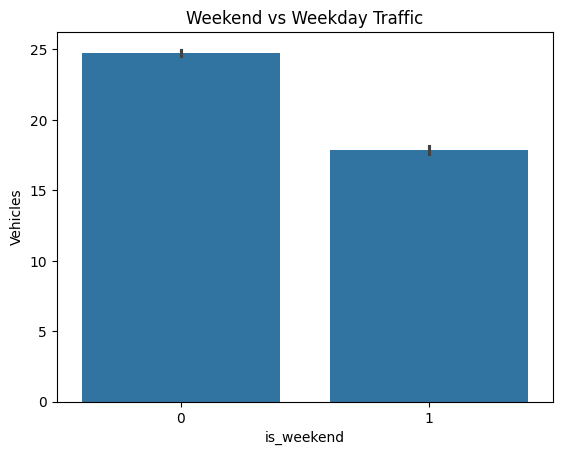

In [16]:
sns.barplot(x='is_weekend', y='Vehicles', data=df)
plt.title("Weekend vs Weekday Traffic")
plt.show()

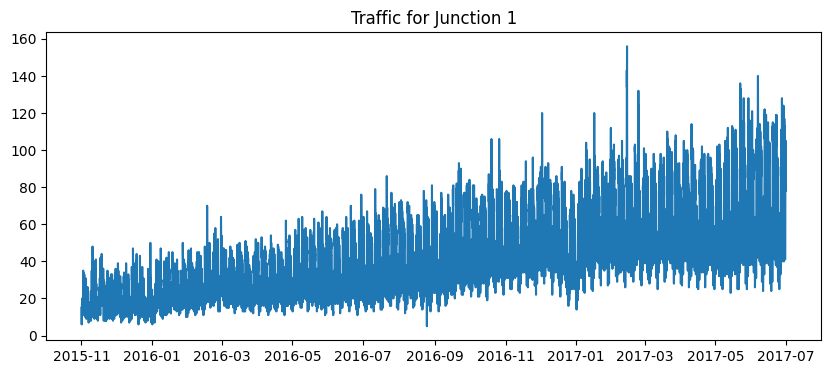

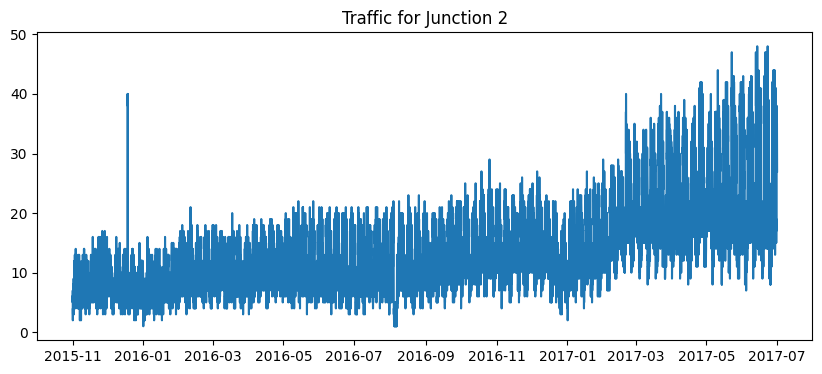

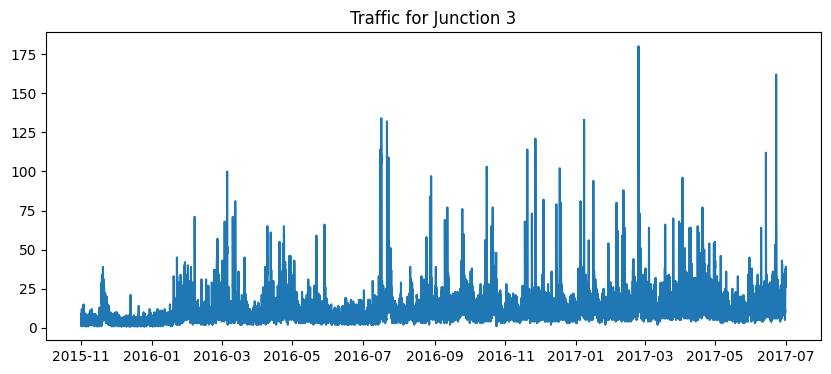

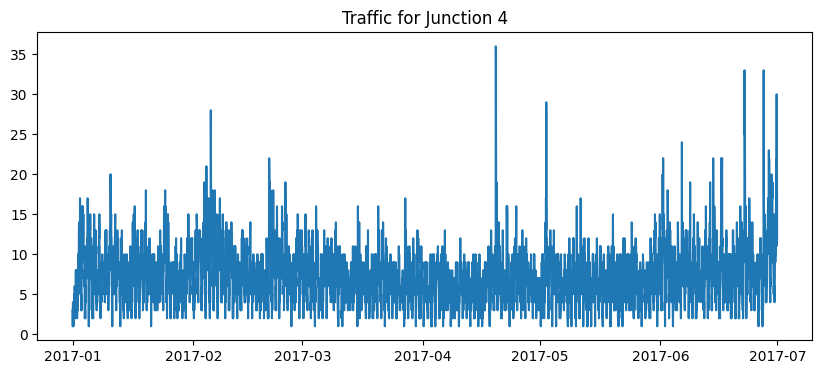

In [17]:
for j in df['Junction'].unique():
    temp = df[df['Junction'] == j]

    plt.figure(figsize=(10,4))
    plt.plot(temp['DateTime'], temp['Vehicles'])
    plt.title(f"Traffic for Junction {j}")
    plt.show()

In [18]:
prophet_df = df[['DateTime', 'Vehicles']]
prophet_df.columns = ['ds', 'y']

In [19]:
!pip install prophet

In [20]:
from prophet import Prophet

model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [21]:
future = model.make_future_dataframe(periods=200)

In [22]:
forecast = model.predict(future)

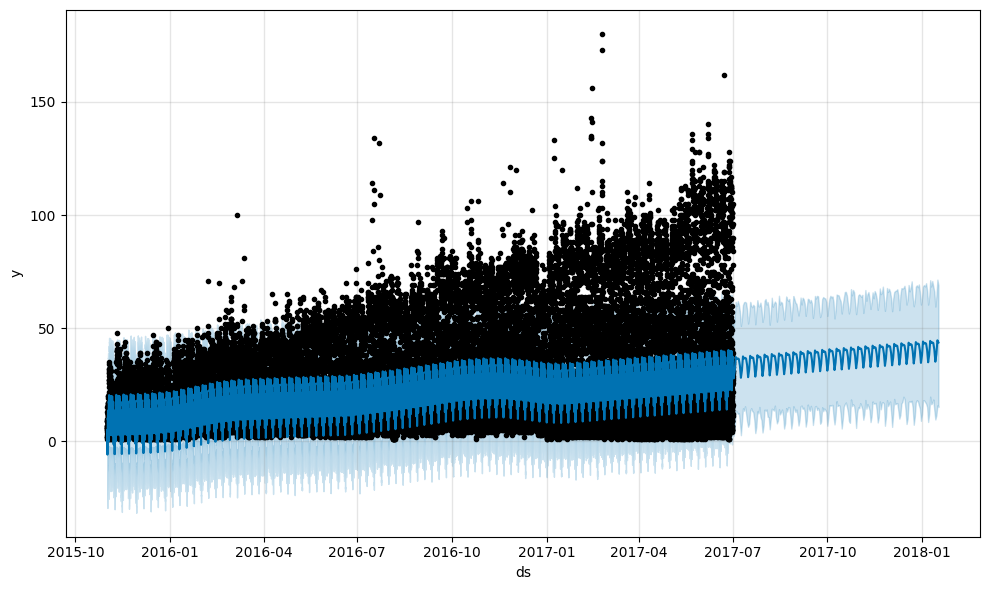

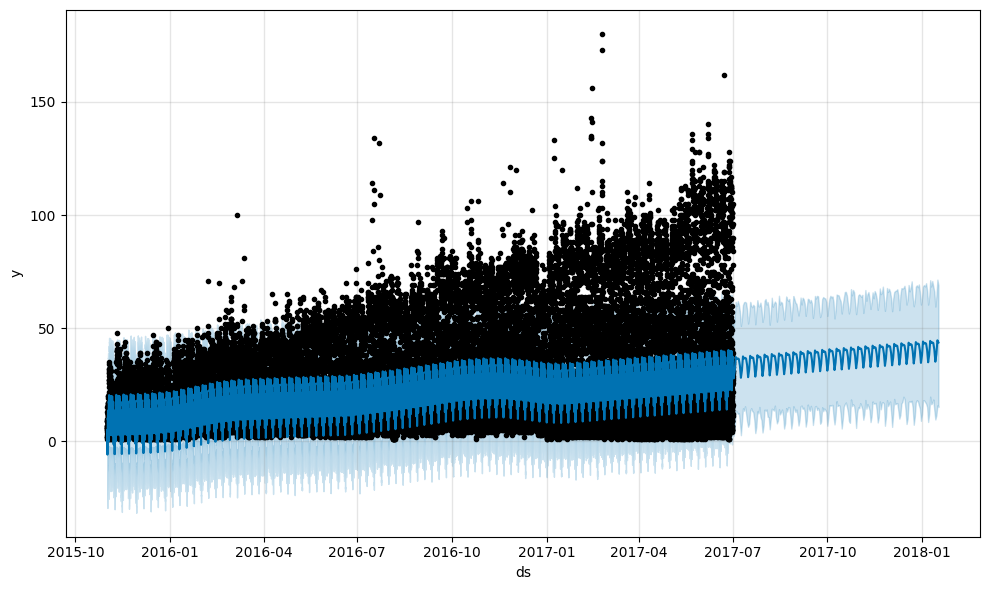

In [23]:
model.plot(forecast)

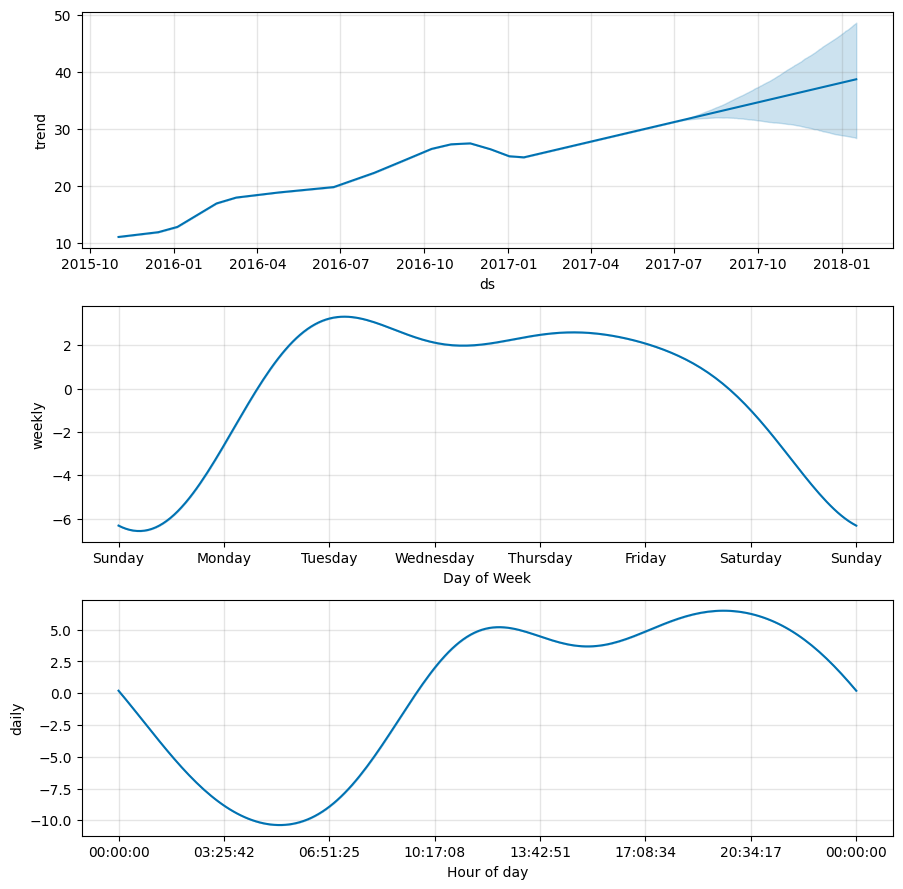

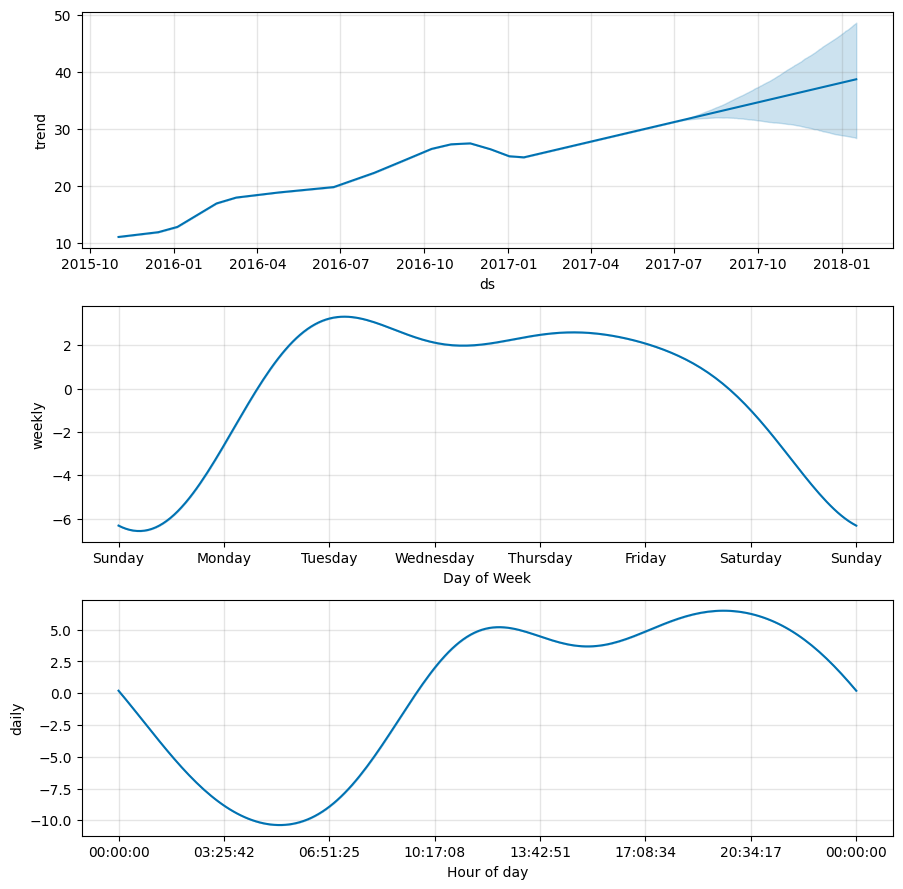

In [24]:
model.plot_components(forecast)

In [26]:
from google.colab import files
uploaded = files.upload()

Saving datasets_8494_11879_test_BdBKkAj.csv to datasets_8494_11879_test_BdBKkAj (1).csv


In [27]:
import os
os.listdir()

['.config',
 'datasets_8494_11879_test_BdBKkAj (1).csv',
 'datasets_8494_11879_test_BdBKkAj.csv',
 'train_aWnotuB.csv',
 'sample_data']

In [29]:
os.listdir()

['.config',
 'datasets_8494_11879_test_BdBKkAj (1).csv',
 'datasets_8494_11879_test_BdBKkAj.csv',
 'train_aWnotuB.csv',
 'sample_data']

In [30]:
df = pd.read_csv("train_aWnotuB.csv")

In [32]:
test_df = pd.read_csv("datasets_8494_11879_test_BdBKkAj.csv")
test_df.head()

,DateTime,Junction,ID
0,2017-07-01 00:00:00,1,20170701001
1,2017-07-01 01:00:00,1,20170701011
2,2017-07-01 02:00:00,1,20170701021
3,2017-07-01 03:00:00,1,20170701031
4,2017-07-01 04:00:00,1,20170701041


In [33]:
test_df['DateTime'] = pd.to_datetime(test_df['DateTime'])

In [34]:
future_test = test_df[['DateTime']]
future_test.columns = ['ds']

In [35]:
test_forecast = model.predict(future_test)

In [36]:
test_df['Predicted_Vehicles'] = test_forecast['yhat']
test_df.head()

,DateTime,Junction,ID,Predicted_Vehicles
0,2017-07-01 00:00:00,1,20170701001,30.384554
1,2017-07-01 01:00:00,1,20170701011,30.384554
2,2017-07-01 02:00:00,1,20170701021,30.384554
3,2017-07-01 03:00:00,1,20170701031,30.384554
4,2017-07-01 04:00:00,1,20170701041,27.179074


In [37]:
test_df.to_csv("traffic_predictions.csv", index=False)

In [38]:
from google.colab import files
files.download("traffic_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
import os
os.listdir()

['.config',
 'datasets_8494_11879_test_BdBKkAj (1).csv',
 'datasets_8494_11879_test_BdBKkAj.csv',
 'train_aWnotuB.csv',
 'traffic_predictions.csv',
 'sample_data']